# Consolidated comparison table (all features x all models)

This notebook consolidates the results presented in the outputs/results.csv file. The idea is to keep the same table but keeping only the best unique combination model x features (best F1 score)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Datasets

In [5]:
df = pd.read_csv("../outputs/results.csv")

print(df.shape)
df.head()

(28, 11)


,timestamp,owner,model_name,feature_description,accuracy,precision_macro,recall_macro,f1_macro,parameters,f1_per_class,notes
0,2026-05-25 09:34:11,NaN,Majority Class Baseline,NaN,0.6475,0.2158,0.3333,0.2620,majority_class=2 (Neutral),"{'Bearish': 0.0, 'Bullish': 0.0, 'Neutral': 0....",NaN
1,2026-05-25 09:34:24,NaN,Logistic Regression Baseline,"TF-IDF (1,1)",0.7685,0.6910,0.7015,0.6955,"ngram_range=(1, 1), min_df=1, max_features=None","{'Bearish': 0.5751633986928104, 'Bullish': 0.6...",NaN
2,2026-05-25 09:34:25,NaN,Logistic Regression Baseline,"TF-IDF (1,2)",0.7800,0.7019,0.7057,0.7038,"ngram_range=(1, 2), min_df=1, max_features=None","{'Bearish': 0.5862068965517241, 'Bullish': 0.6...",NaN
3,2026-05-25 09:34:26,NaN,Logistic Regression Baseline,"TF-IDF (1,2) Optimized",0.7795,0.7021,0.7175,0.7091,"ngram_range=(1, 2), min_df=2, max_features=25000","{'Bearish': 0.5980392156862745, 'Bullish': 0.6...",NaN
4,2026-05-25 09:34:27,NaN,KNN Baseline,"TF-IDF (1,2) Optimized",0.6888,0.7305,0.4212,0.4247,n_neighbors=3,"{'Bearish': 0.21114369501466276, 'Bullish': 0....",NaN


## 2. Uniformize Model Names

In [7]:
df["model_name"] = (
    df["model_name"]
    .replace({
        "Logistic Regression Baseline": "Logistic Regression",
        "KNN Baseline": "KNN",
        "Multinomial NB Baseline": "Multinomial NB",
        "Random Forest Baseline": "Random Forest",
        "XGBoost Baseline": "XGBoost",
        "MLP Classifier": "MLP",
    })
)

## 3. Select best configuration per unique combination model_name x feature_description

In [10]:
best_results = (
    df.sort_values("f1_macro", ascending=False)
      .drop_duplicates(
          subset=["model_name", "feature_description"],
          keep="first"
      )
)

best_results

,timestamp,owner,model_name,feature_description,accuracy,precision_macro,recall_macro,f1_macro,parameters,f1_per_class,notes
19,2026-05-25 10:48:06,La Feria,DistilBERT,HF fine-tune,0.8628,0.8361,0.7964,0.8143,"model=distilbert-base-uncased, max_length=128","{'Bearish': 0.7340823970037453, 'Bullish': 0.8...","TM-024 final DistilBERT, full data, lr=2e-5, b..."
3,2026-05-25 09:34:26,NaN,Logistic Regression,"TF-IDF (1,2) Optimized",0.7795,0.7021,0.7175,0.7091,"ngram_range=(1, 2), min_df=2, max_features=25000","{'Bearish': 0.5980392156862745, 'Bullish': 0.6...",NaN
12,2026-05-25 09:35:36,NaN,MLP,"TF-IDF (1,2) Optimized",0.8025,0.7590,0.6728,0.7051,"hidden_layer_sizes=(100, 50), learning_rate_in...","{'Bearish': 0.5585215605749486, 'Bullish': 0.6...",NaN
2,2026-05-25 09:34:25,NaN,Logistic Regression,"TF-IDF (1,2)",0.7800,0.7019,0.7057,0.7038,"ngram_range=(1, 2), min_df=1, max_features=None","{'Bearish': 0.5862068965517241, 'Bullish': 0.6...",NaN
1,2026-05-25 09:34:24,NaN,Logistic Regression,"TF-IDF (1,1)",0.7685,0.6910,0.7015,0.6955,"ngram_range=(1, 1), min_df=1, max_features=None","{'Bearish': 0.5751633986928104, 'Bullish': 0.6...",NaN
10,2026-05-25 09:34:37,NaN,Multinomial NB,"TF-IDF (1,2) Optimized",0.7863,0.7527,0.6415,0.6791,alpha=0.1,"{'Bearish': 0.5411255411255411, 'Bullish': 0.6...",NaN
14,2026-05-25 09:35:37,NaN,Random Forest,"TF-IDF (1,2) Optimized",0.7402,0.6585,0.6287,0.6412,"n_estimators=200, max_depth=20, class_weight=b...","{'Bearish': 0.5142857142857142, 'Bullish': 0.5...",NaN
25,2026-05-31 07:48:38,Bento,MLP,GloVe-Twitter-100 Mean Pooling,0.7412,0.6412,0.6091,0.6226,"hidden_layer_sizes=(128,), activation=relu, so...","{'Bearish': 0.46616541353383456, 'Bullish': 0....",NaN
27,2026-05-31 07:49:08,Bento,MLP,GloVe-Twitter-100 TF-IDF Weighted Pooling,0.7025,0.6008,0.5856,0.5924,"hidden_layer_sizes=(128,), activation=relu, so...","{'Bearish': 0.47232472324723246, 'Bullish': 0....",NaN
18,2026-05-25 09:42:52,NaN,Logistic Regression,GloVe-Twitter-100 Mean Pooling,0.6590,0.5735,0.6181,0.5855,"vector_size=100, pre-trained, penalty=l2, clas...","{'Bearish': 0.4422535211267606, 'Bullish': 0.5...",NaN


In [11]:
best_results.to_csv(
    "../outputs/results_best.csv",
    index=False
)

## 4. Create a clean table with the results

In [12]:
report_table = best_results[
    [
        "model_name",
        "feature_description",
        "f1_macro"
    ]
].copy()

report_table = report_table.rename(columns={
    "model_name": "Model",
    "feature_description": "Feature",
    "f1_macro": "Macro_F1"
})

report_table = report_table.sort_values(
    "Macro_F1",
    ascending=False
)

report_table["Macro_F1"] = report_table["Macro_F1"].round(4)

report_table

,Model,Feature,Macro_F1
19,DistilBERT,HF fine-tune,0.8143
3,Logistic Regression,"TF-IDF (1,2) Optimized",0.7091
12,MLP,"TF-IDF (1,2) Optimized",0.7051
2,Logistic Regression,"TF-IDF (1,2)",0.7038
1,Logistic Regression,"TF-IDF (1,1)",0.6955
10,Multinomial NB,"TF-IDF (1,2) Optimized",0.6791
14,Random Forest,"TF-IDF (1,2) Optimized",0.6412
25,MLP,GloVe-Twitter-100 Mean Pooling,0.6226
27,MLP,GloVe-Twitter-100 TF-IDF Weighted Pooling,0.5924
18,Logistic Regression,GloVe-Twitter-100 Mean Pooling,0.5855


In [13]:
report_table.to_csv(
    "../outputs/report_BestResultsTable.csv",
    index=False
)

## 5. Create a bar chart to visualize the results above

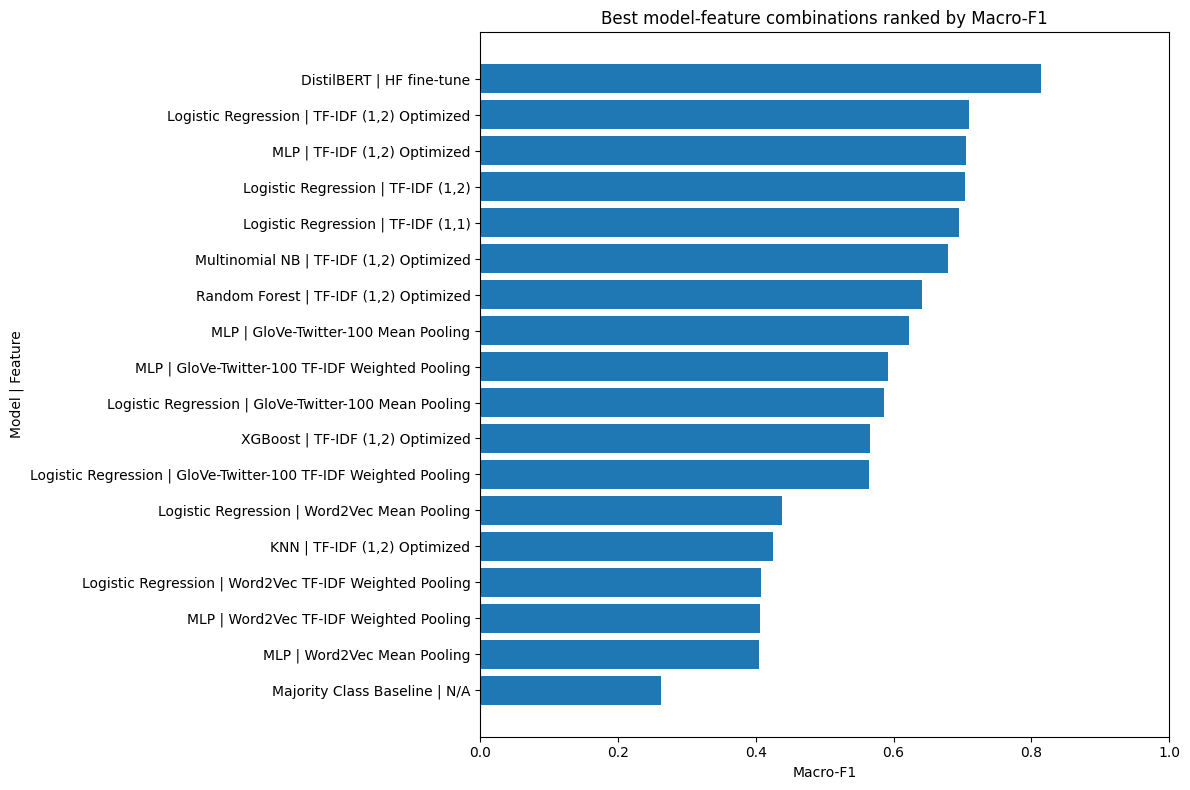

In [17]:
import matplotlib.pyplot as plt

plot_df = report_table.copy()

plot_df["Model"] = plot_df["Model"].fillna("Unknown").astype(str)
plot_df["Feature"] = plot_df["Feature"].fillna("N/A").astype(str)
plot_df["Macro_F1"] = plot_df["Macro_F1"].astype(float)

plot_df["Model_Feature"] = (
    plot_df["Model"] + " | " + plot_df["Feature"]
)

plot_df = plot_df.sort_values("Macro_F1", ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["Model_Feature"],
    plot_df["Macro_F1"]
)

plt.xlabel("Macro-F1")
plt.ylabel("Model | Feature")
plt.title("Best model-feature combinations ranked by Macro-F1")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    "../outputs/report_bar_chart_macro_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()